# 4주차: 다층 신경망 (MLP) — 해설


---

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
torch.manual_seed(42); np.random.seed(42)


### A-1

In [ ]:
z = torch.tensor([-3.0, -1.0, 0.0, 1.0, 3.0])
my_sigmoid = 1 / (1 + torch.exp(-z))
my_tanh    = (torch.exp(z) - torch.exp(-z)) / (torch.exp(z) + torch.exp(-z))
my_relu    = torch.clamp(z, min=0)
print("Sigmoid:", torch.allclose(my_sigmoid, torch.sigmoid(z)))
print("Tanh:   ", torch.allclose(my_tanh,    torch.tanh(z)))
print("ReLU:   ", torch.allclose(my_relu,    torch.relu(z)))


Sigmoid: True
Tanh:    True
ReLU:    True


### A-2

In [ ]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        a1  = torch.relu(self.fc1(x))      # ← 정답
        out = torch.sigmoid(self.fc2(a1))  # ← 정답
        return out
print("Output shape:", SimpleMLP(3,5)(torch.randn(10,3)).shape)


Output shape: torch.Size([10, 1])


### A-3

In [ ]:
model_count = nn.Sequential(nn.Linear(2,8), nn.ReLU(), nn.Linear(8,1), nn.Sigmoid())
total_params = sum(p.numel() for p in model_count.parameters() if p.requires_grad)
print(f"Total: {total_params}")  # 2*8+8 + 8*1+1 = 33


Total: 33


In [ ]:
for p in model_count.parameters():
  print(p, type(p))

Parameter containing:
tensor([[ 0.6804, -0.5836],
        [-0.7014, -0.5532],
        [-0.4757,  0.2864],
        [ 0.2532,  0.5876],
        [-0.3652, -0.4820],
        [ 0.3752, -0.2858],
        [ 0.4292, -0.1678],
        [ 0.4045, -0.5494]], requires_grad=True) <class 'torch.nn.parameter.Parameter'>
Parameter containing:
tensor([-0.3568,  0.2156,  0.1495, -0.1803,  0.4215,  0.4807, -0.5128, -0.3775],
       requires_grad=True) <class 'torch.nn.parameter.Parameter'>
Parameter containing:
tensor([[ 0.3237, -0.1193, -0.1253, -0.3421, -0.2025,  0.0883, -0.0467, -0.2566]],
       requires_grad=True) <class 'torch.nn.parameter.Parameter'>
Parameter containing:
tensor([0.0083], requires_grad=True) <class 'torch.nn.parameter.Parameter'>


In [6]:
pip install torchinfo

In [7]:
from torchinfo import summary

summary(model_count, input_size=(1, 2))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1]                    --
├─Linear: 1-1                            [1, 8]                    24
├─ReLU: 1-2                              [1, 8]                    --
├─Linear: 1-3                            [1, 1]                    9
├─Sigmoid: 1-4                           [1, 1]                    --
Total params: 33
Trainable params: 33
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

### A-4

In [8]:
y_true = torch.tensor([1.0, 0.0, 1.0, 1.0, 0.0])
y_pred = torch.tensor([0.9, 0.1, 0.8, 0.6, 0.3])
my_bce = -torch.mean(y_true * torch.log(y_pred) + (1-y_true) * torch.log(1-y_pred))
print(f"My BCE:      {my_bce.item():.6f}")
print(f"PyTorch BCE: {nn.BCELoss()(y_pred, y_true).item():.6f}")


My BCE:      0.260273
PyTorch BCE: 0.260273


### A-5

In [9]:
X_xor = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y_xor = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)
torch.manual_seed(0)
model_a5 = SimpleMLP(2,4)
optimizer_a5 = torch.optim.Adam(model_a5.parameters(), lr=0.1)
criterion_a5 = nn.BCELoss()
for epoch in range(500):
    optimizer_a5.zero_grad()              # ← 정답
    pred = model_a5(X_xor)
    loss = criterion_a5(pred, y_xor)      # ← 정답
    loss.backward()                       # ← 정답
    optimizer_a5.step()                   # ← 정답
print(f"Final loss: {loss.item():.5f}")


Final loss: 0.00039


### A-6

In [ ]:
with torch.no_grad():                        # ← 정답
    predictions      = model_a5(X_xor)
    predicted_labels = (predictions > 0.5).int()
print("Predictions:", predicted_labels.T)
print("True labels:", y_xor.T.int())


Predictions: tensor([[0, 1, 1, 0]], dtype=torch.int32)
True labels: tensor([[0, 1, 1, 0]], dtype=torch.int32)


In [ ]:
predictions > 0.5

tensor([[False],
        [ True],
        [ True],
        [False]])

In [ ]:
predicted_labels

tensor([[0],
        [1],
        [1],
        [0]], dtype=torch.int32)

In [ ]:
a=torch.tensor([1,2,3])
np_arr=np.array([1,2,3])
b=torch.from_numpy(np_arr)  # shares memory with numpy object
c=torch.tensor(np_arr)  # copies the object
np_arr[0]=100
print(np_arr,a,b,c)
b[1]=200
print(np_arr,a,b,c)

[100   2   3] tensor([1, 2, 3]) tensor([100,   2,   3]) tensor([1, 2, 3])
[100 200   3] tensor([1, 2, 3]) tensor([100, 200,   3]) tensor([1, 2, 3])


### A-7

In [ ]:
with torch.no_grad():
    A1 = torch.relu(model_a5.fc1(X_xor))   # ← 정답
print("Shape:", A1.shape)
for xi, ai in zip(X_xor, A1):
    print(f"  x={xi.tolist()} → A1={ai.numpy().round(3)}")


Shape: torch.Size([4, 4])
  x=[0.0, 0.0] → A1=[0.    2.844 0.    0.   ]
  x=[0.0, 1.0] → A1=[0. 0. 0. 0.]
  x=[1.0, 0.0] → A1=[0. 0. 0. 0.]
  x=[1.0, 1.0] → A1=[2.883 0.    0.    0.   ]


### A-8

In [15]:
results = {}
X_xor = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y_xor = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)
for act_name in ['relu', 'tanh']:
    torch.manual_seed(42)
    act_layer = nn.ReLU() if act_name == 'relu' else nn.Tanh()   # ← 정답
    model_act = nn.Sequential(nn.Linear(2,8), act_layer, nn.Linear(8,1), nn.Sigmoid())
    opt = torch.optim.Adam(model_act.parameters(), lr=0.1)
    for _ in range(500):
        opt.zero_grad(); l = nn.BCELoss()(model_act(X_xor), y_xor); l.backward(); opt.step()
    results[act_name] = l.item()
for name, v in results.items():
    print(f"{name:6s} final loss: {v:.6f}")


relu   final loss: 0.000498
tanh   final loss: 0.000094


### B-1

In [ ]:
X_np, y_np = make_moons(n_samples=600, noise=0.25, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_np,y_np, test_size=0.2, random_state=42)
X_train = torch.tensor(X_tr, dtype=torch.float32); y_train = torch.tensor(y_tr,dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(X_te, dtype=torch.float32); y_test  = torch.tensor(y_te,dtype=torch.float32).unsqueeze(1)

torch.manual_seed(42)
model_b1     = SimpleMLP(input_dim=2, hidden_dim=16)                          # ← 정답
criterion_b1 = nn.BCELoss()                                                   # ← 정답
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=0.01)              # ← 정답

train_losses_b1 = []
for epoch in range(1000):                                                     # ← 정답
    optimizer_b1.zero_grad()
    loss = criterion_b1(model_b1(X_train), y_train)
    loss.backward(); optimizer_b1.step()
    train_losses_b1.append(loss.item())

with torch.no_grad():
    test_pred = (model_b1(X_test) > 0.5).float()                             # ← 정답
    acc = (test_pred == y_test).float().mean().item()                         # ← 정답
print(f"Test Accuracy: {acc*100:.1f}%")

Test Accuracy: 93.3%


In [ ]:

train_losses_b1 = []
for epoch in range(1000):                                                     # ← 정답
    optimizer_b1.zero_grad()
    loss = criterion_b1(model_b1(X_train), y_train)
    loss.backward(); optimizer_b1.step()
    train_losses_b1.append(loss.item())

with torch.no_grad():
    test_pred = (model_b1(X_test) > 0.5).float()                             # ← 정답
    acc = (test_pred == y_test).float().mean().item()                         # ← 정답
print(f"Test Accuracy: {acc*100:.1f}%")


In [ ]:
X_np, y_np = make_moons(n_samples=600, noise=0.25, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_np,y_np, test_size=0.2, random_state=42)
X_train = torch.tensor(X_tr, dtype=torch.float32); y_train = torch.tensor(y_tr,dtype=torch.float32).unsqueeze(1)
X_test  = torch.tensor(X_te, dtype=torch.float32); y_test  = torch.tensor(y_te,dtype=torch.float32).unsqueeze(1)

torch.manual_seed(42)
model_b1     = SimpleMLP(input_dim=2, hidden_dim=16)                          # ← 정답
criterion_b1 = nn.BCELoss()                                                   # ← 정답
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=0.01)              # ← 정답

train_losses_b1 = []
for epoch in range(1000):                                                     # ← 정답
    optimizer_b1.zero_grad()
    loss = criterion_b1(model_b1(X_train), y_train)
    loss.backward(); optimizer_b1.step()
    train_losses_b1.append(loss.item())

with torch.no_grad():
    test_pred = (model_b1(X_test) > 0.5).float()                             # ← 정답
    acc = (test_pred == y_test).float().mean().item()                         # ← 정답
print(f"Test Accuracy: {acc*100:.1f}%")


### B-2 (숙제)

Random Init: tensor([[0, 1, 1, 0]], dtype=torch.int32) ← 정답!
Zero Init:   tensor([[0, 0, 0, 0]], dtype=torch.int32) ← symmetry 문제
True labels: tensor([[0, 1, 1, 0]], dtype=torch.int32)


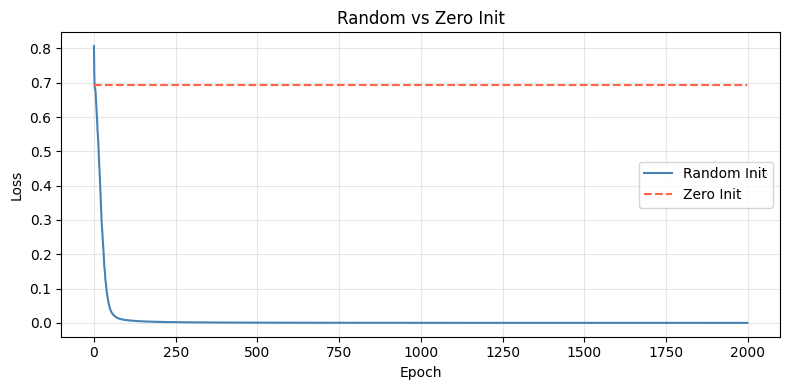

In [20]:
XOR_X = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
XOR_y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

def train_and_eval(model, epochs=2000, lr=0.1):
    crit = nn.BCELoss()                                    # ← 정답
    opt  = torch.optim.Adam(model.parameters(), lr=lr)    # ← 정답
    losses = []
    for _ in range(epochs):
        opt.zero_grad(); out=model(XOR_X); loss=crit(out,XOR_y); loss.backward(); opt.step()
        losses.append(loss.item())
    with torch.no_grad():
        preds = (model(XOR_X) > 0.5).int()
    return losses, preds

torch.manual_seed(42)
model_rand = SimpleMLP(2,4)
losses_rand, preds_rand = train_and_eval(model_rand)

torch.manual_seed(42)
model_zero = SimpleMLP(2,4)
model_zero.fc1.weight.data.fill_(0); model_zero.fc1.bias.data.fill_(0)   # ← 정답
model_zero.fc2.weight.data.fill_(0); model_zero.fc2.bias.data.fill_(0)   # ← 정답
losses_zero, preds_zero = train_and_eval(model_zero)

print("Random Init:", preds_rand.T, "← 정답!")
print("Zero Init:  ", preds_zero.T, "← symmetry 문제")
print("True labels:", XOR_y.T.int())

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(losses_rand, label='Random Init', color='steelblue')    # ← 정답
ax.plot(losses_zero, label='Zero Init',   color='tomato', linestyle='--')  # ← 정답
ax.set_title("Random vs Zero Init"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()   # ← 정답


---
## 강사 노트

### A-1
- `my_tanh` 수치 불안정 가능 → `torch.tanh()` 권장 이유 설명
- ReLU 대안: `z * (z > 0).float()` — boolean masking

### A-3
- Linear$(n \to m)$: 파라미터 수 $= n \times m + m$ 암기
- `p.requires_grad` 필터 → frozen layer 복선 (10주차)

### B-2
- Zero init: loss 전혀 감소 안 함 → symmetry 직접 관찰
- "이래서 Xavier/He 초기화 필요" → 6주차 복선
